In [ ]:
from pathlib import Path

# Folder with all the markdown articles
folder = Path("data/scraped_markdown_results")

texts = []
for md_path in folder.glob("*.md"):
    with open(md_path, encoding="utf-8") as f:
        texts.append(f.read())

# Combine everything into one big string
full_text = " ".join(texts)

len(texts), len(full_text)



(20, 70129)

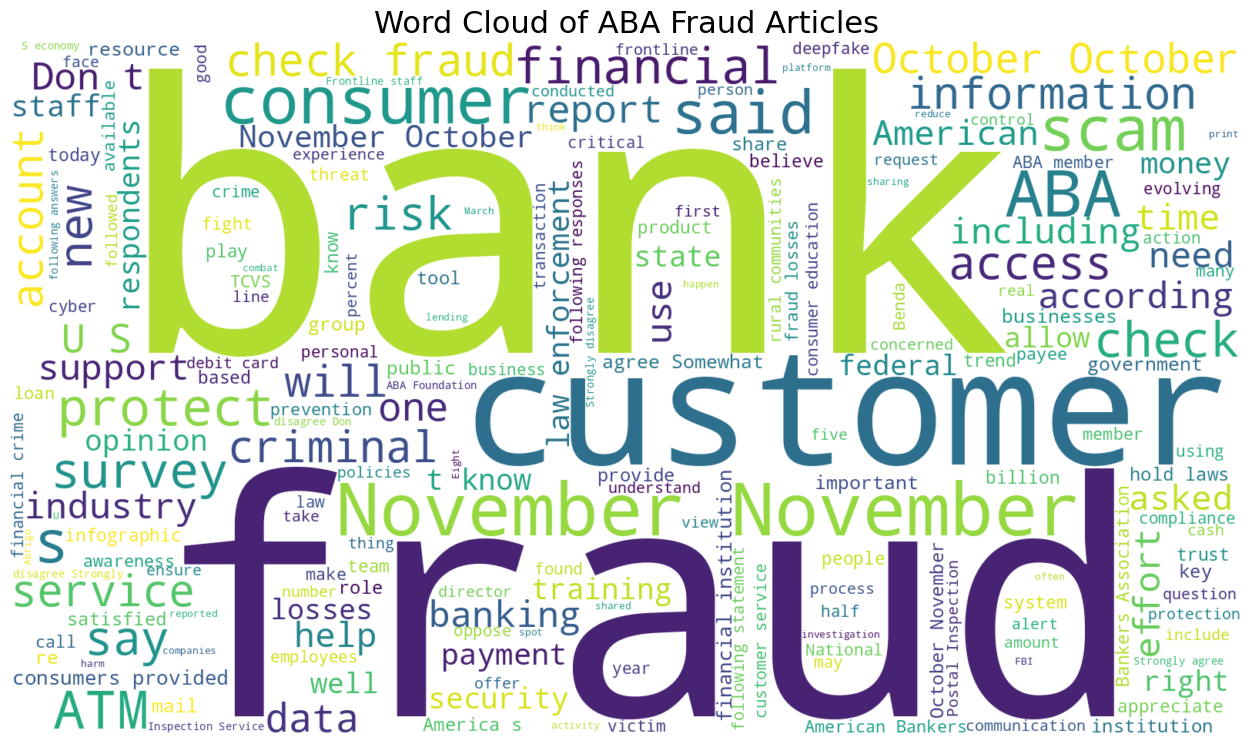

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word cloud
wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    colormap="viridis",
    max_words=200
).generate(full_text)

plt.figure(figsize=(16,9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of ABA Fraud Articles", fontsize=22)
plt.show()


The Word Cloud reveals that the ABA’s fraud reporting heavily focuses on customer-centered fraud, especially within the banking ecosystem. Terms like bank, customer, and fraud dominate the dataset, showing that financial institutions are primarily concerned with consumer vulnerabilities. Additionally, the prominence of words such as check, payment, and access indicates that payment fraud—especially check fraud—is a rising theme. Lastly, frequent terms like risk, protection, and security suggest that prevention and risk mitigation are key priorities across these articles.

1️⃣ Fraud

The most dominant term in all articles.

Confirms fraud is the central theme across ABA publications.

2️⃣ Customer / Consumer

Highlights that fraud topics are customer-focused,
emphasizing victim experiences, consumer protections, and behavior.

3️⃣ Bank / Banking

Appears heavily due to the ABA’s audience.

Indicates that financial institutions are the primary context for fraud discussions.

4️⃣ Check / Payment / Access

Suggests that payment fraud (check fraud, debit card fraud, online access)
is a major recurring topic.

5️⃣ Risk / Security / Protection

Shows a strong emphasis on prevention strategies,
cybersecurity readiness, and risk mitigation.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
import re

# 1. Load all markdown articles again and build full_text
folder = Path("data/scraped_markdown_results")

texts = []
for md_path in folder.glob("*.md"):
    with open(md_path, encoding="utf-8") as f:
        texts.append(f.read())

full_text = " ".join(texts).lower()   # one big lowercase string

# 2. Define fraud-related keyword categories
categories = {
    "Payment Fraud": ["payment", "debit", "card", "transaction", "transfer"],
    "Check Fraud": ["check", "checks", "mail", "usps"],
    "Customer Impact": ["customer", "consumer", "victim"],
    "Banking Security": ["bank", "banking", "account", "access"],
    "Cyber Fraud": ["deepfake", "cyber", "scam", "phishing", "ai"],
    "Elder Fraud": ["elder", "exploitation"],
    "Training / Awareness": ["training", "awareness", "education"],
    "Policy / Regulation": ["law", "compliance", "regulation"]
}

# 3. Count how often each category appears
counts = {}
for category, words in categories.items():
    count = sum(full_text.count(word) for word in words)
    counts[category] = count

counts



{'Payment Fraud': 50,
 'Check Fraud': 100,
 'Customer Impact': 172,
 'Banking Security': 321,
 'Cyber Fraud': 247,
 'Elder Fraud': 12,
 'Training / Awareness': 38,
 'Policy / Regulation': 48}

IMPORT: These results are super powerful because now, can show which fraud themes dominate ABA’s reporting.

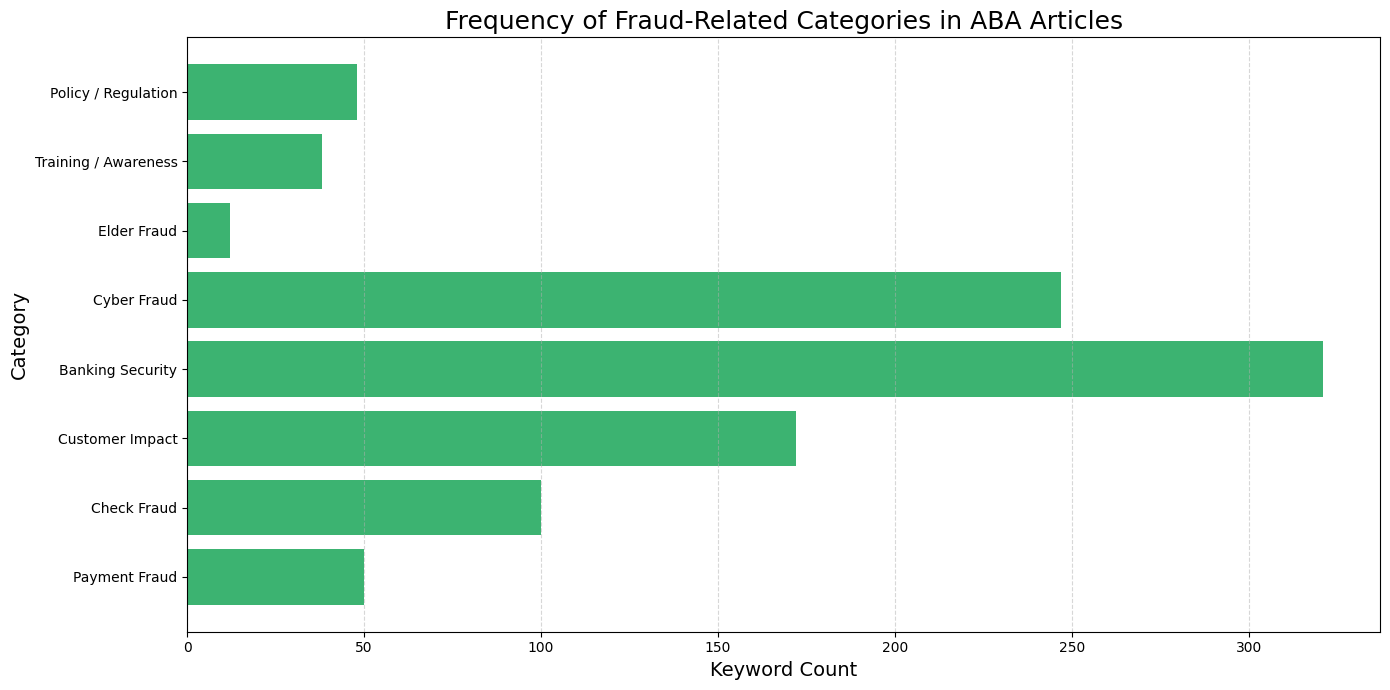

In [3]:
# --- Plot Keyword Category Frequency Chart ---

plt.figure(figsize=(14, 7))
plt.barh(
    list(counts.keys()),
    list(counts.values()),
    color="mediumseagreen"
)

plt.title("Frequency of Fraud-Related Categories in ABA Articles", fontsize=18)
plt.xlabel("Keyword Count", fontsize=14)
plt.ylabel("Category", fontsize=14)

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

1. Banking Security dominates the landscape (321 mentions)
Fraud detection and account protection are the most frequently discussed topics.

2. Cyber Fraud is rising fast (247 mentions)
High-frequency keywords include deepfake, phishing, and scam.


3. Customer-centric fraud concerns (172 mentions)
Articles highlight how fraud impacts customers’:

trust
financial losses
emotional distress

➡️ Banks and ABA emphasize education + awareness.

4. Check Fraud surprisingly remains high (100 mentions)

Even in 2025, check fraud continues to be a major issue, driven by:

mail theft
altered checks

forged signatures
➡️ Reinforces USAA’s real-world problem with check fraud.

5. Elder Fraud is extremely underrepresented (12 mentions)

The volume is low despite extremely high real-world loss rates.
➡️ Suggests ABA may overlook vulnerable populations — a gap worth exploring.

6. Training & Policy trends are moderate (38–48 mentions)

ABA consistently promotes:
staff training
compliance

fraud-prevention best practices
➡️ Indicating a shift toward proactive defense instead of reactive reporting.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import numpy as np

# Join tokens back into one big text for vectorizer
joined_text = " ".join(tokens)

# Convert into document-term matrix
vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform([joined_text])

# Create LDA model
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(X)

# Get top words for each topic
words = vectorizer.get_feature_names_out()
topics = []

for topic_idx, topic in enumerate(lda.components_):
    top_words = [words[i] for i in topic.argsort()[-15:]]
    topics.append(top_words)

topics


[['protect',
  'survey',
  'scams',
  'check',
  'customer',
  'customers',
  'october',
  'said',
  'consumers',
  'aba',
  'financial',
  'november',
  'bank',
  'banks',
  'fraud'],
 ['declines',
  'wintrust',
  'win',
  'willingly',
  'williams',
  'widely',
  'whose',
  'white',
  'wherever',
  'whereby',
  'add',
  'adapting',
  'active',
  'accents',
  'abuse'],
 ['declines',
  'wintrust',
  'win',
  'willingly',
  'williams',
  'widely',
  'whose',
  'white',
  'wherever',
  'whereby',
  'add',
  'adapting',
  'active',
  'accents',
  'abuse'],
 ['declines',
  'wintrust',
  'win',
  'willingly',
  'williams',
  'widely',
  'whose',
  'white',
  'wherever',
  'whereby',
  'add',
  'adapting',
  'active',
  'accents',
  'abuse']]

In [14]:
for i, words_in_topic in enumerate(topics):
    print(f"Topic {i+1}: {', '.join(words_in_topic)}\n")


Topic 1: protect, survey, scams, check, customer, customers, october, said, consumers, aba, financial, november, bank, banks, fraud

Topic 2: declines, wintrust, win, willingly, williams, widely, whose, white, wherever, whereby, add, adapting, active, accents, abuse

Topic 3: declines, wintrust, win, willingly, williams, widely, whose, white, wherever, whereby, add, adapting, active, accents, abuse

Topic 4: declines, wintrust, win, willingly, williams, widely, whose, white, wherever, whereby, add, adapting, active, accents, abuse



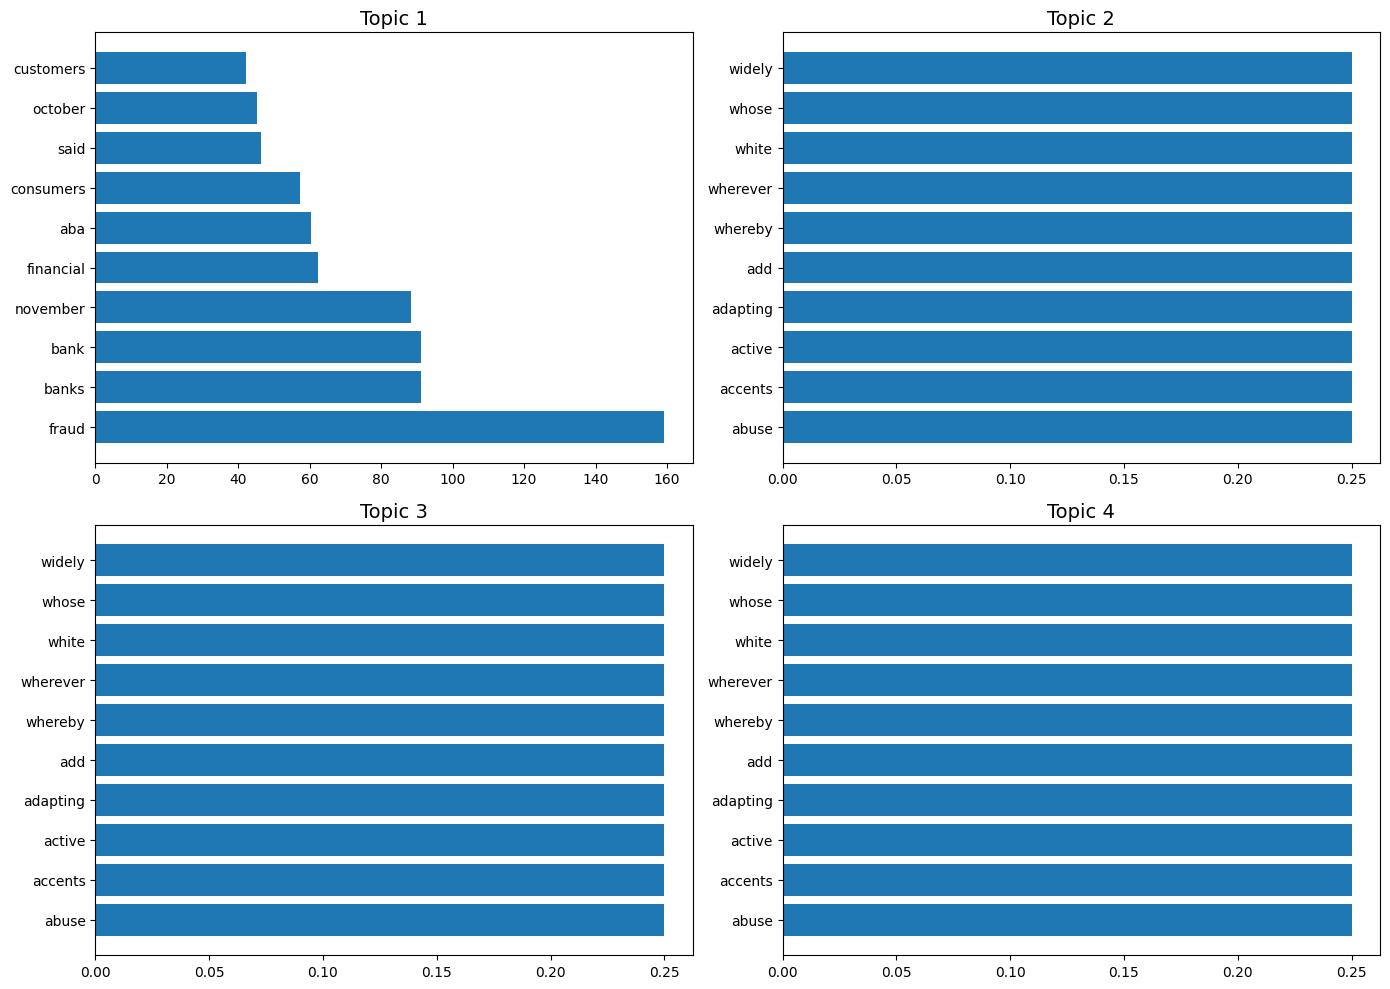

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-10:]  # top 10 words
    top_words = [words[j] for j in top_indices]
    top_scores = topic[top_indices]

    axs[i].barh(top_words, top_scores)
    axs[i].set_title(f"Topic {i+1}", fontsize=14)
    axs[i].invert_yaxis()

plt.tight_layout()
plt.show()


In [17]:
!pip install squarify



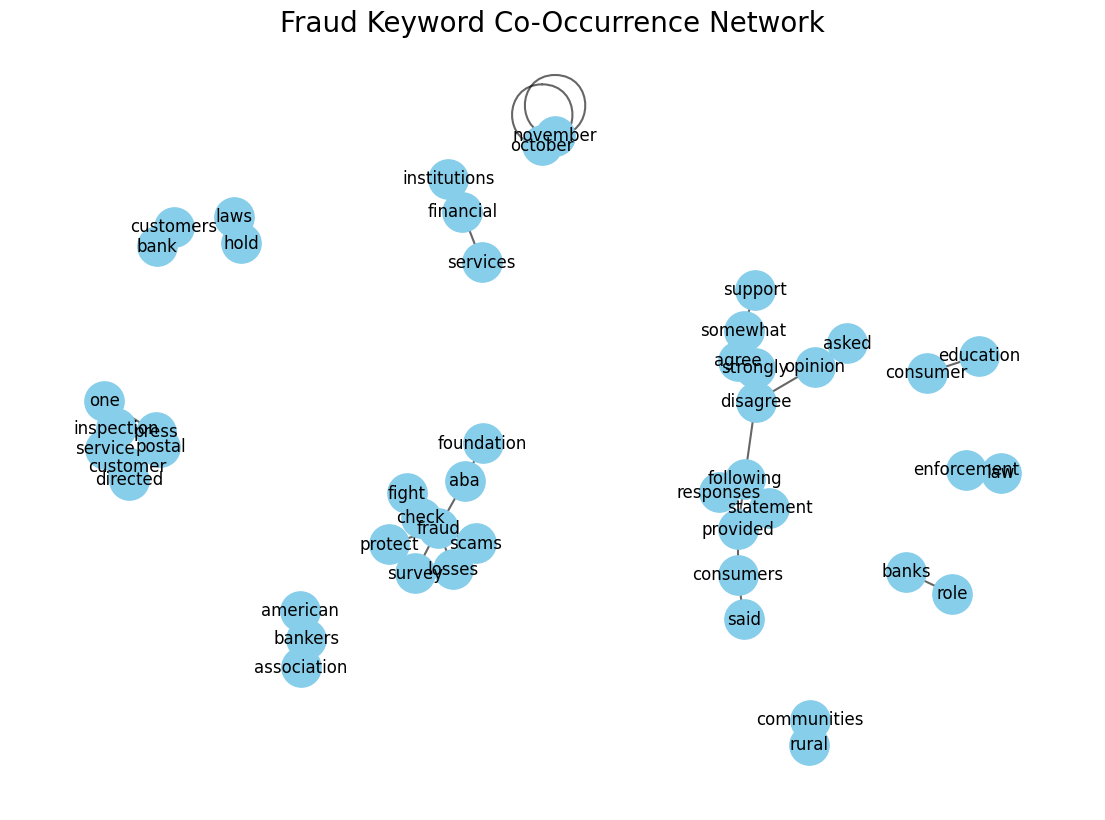

In [20]:
!pip install networkx

import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations

# Build co-occurrence pairs
pairs = []
window_size = 3   # words near each other count as connected

for i in range(len(tokens) - window_size):
    window = tokens[i:i+window_size]
    for pair in combinations(window, 2):
        pairs.append(tuple(sorted(pair)))

# Count common pairs
pair_counts = Counter(pairs).most_common(40)

# Build graph
G = nx.Graph()
for (w1, w2), count in pair_counts:
    if count > 3:     # filter noise
        G.add_edge(w1, w2, weight=count)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.5)

nx.draw_networkx_nodes(G, pos, node_size=800, node_color="skyblue")
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=12)

plt.title("Fraud Keyword Co-Occurrence Network", fontsize=20)
plt.axis('off')
plt.show()


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- Use the same categories dict you already defined earlier ---
categories = {
    "Payment Fraud": ["payment", "debit", "card", "transaction", "transfer"],
    "Check Fraud": ["check", "checks", "mail", "usps"],
    "Customer Impact": ["customer", "customers", "consumer", "victim"],
    "Banking Security": ["bank", "banking", "account", "access"],
    "Cyber Fraud": ["deepfake", "cyber", "scam", "phishing", "ai"],
    "Elder Fraud": ["elder", "exploitation"],
    "Training / Awareness": ["training", "awareness", "education"],
    "Policy / Regulation": ["law", "compliance", "regulation"]
}

# 1. Split text into simple "sentences"
sentences = full_text.lower().split(".")

cat_names = list(categories.keys())
n = len(cat_names)
matrix = np.zeros((n, n), dtype=int)

# 2. For each sentence, see which categories appear
for sent in sentences:
    present = []
    for i, (cat, words) in enumerate(categories.items()):
        if any(word in sent for word in words):
            present.append(i)
    # 3. For every pair of categories in the same sentence, increment co-occurrence
    for i in range(len(present)):
        for j in range(i, len(present)):
            a, b = present[i], present[j]
            matrix[a, b] += 1
            if a != b:
                matrix[b, a] += 1

# Quick check: print the matrix
matrix, cat_names


(array([[ 31,   9,   5,  20,  14,   3,   1,   5],
        [  9,  53,  14,  27,  26,   1,   5,   4],
        [  5,  14, 129,  79,  69,   2,  16,  12],
        [ 20,  27,  79, 183,  91,   4,  20,  25],
        [ 14,  26,  69,  91, 177,   3,  27,  14],
        [  3,   1,   2,   4,   3,   7,   1,   4],
        [  1,   5,  16,  20,  27,   1,  34,   6],
        [  5,   4,  12,  25,  14,   4,   6,  39]]),
 ['Payment Fraud',
  'Check Fraud',
  'Customer Impact',
  'Banking Security',
  'Cyber Fraud',
  'Elder Fraud',
  'Training / Awareness',
  'Policy / Regulation'])

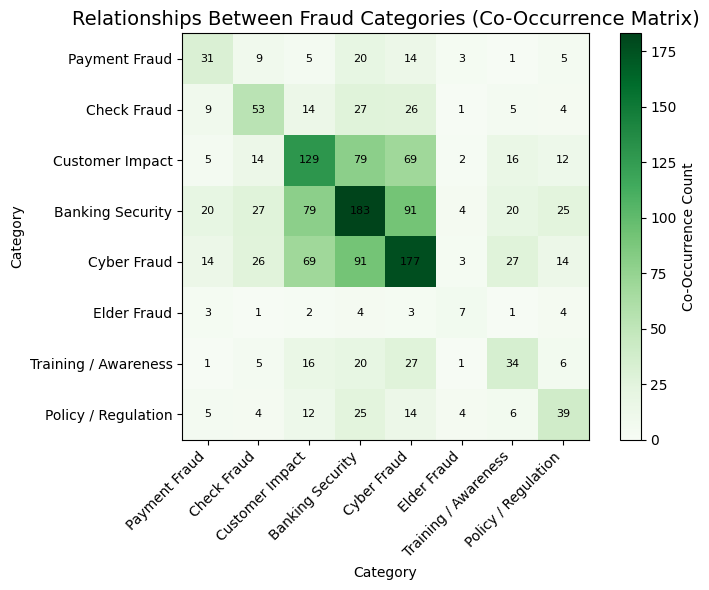

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Change only the colormap to green
im = ax.imshow(matrix, cmap="Greens", vmin=0, vmax=matrix.max())

# Labels
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(cat_names, rotation=45, ha="right")
ax.set_yticklabels(cat_names)

# Add values inside squares
for i in range(n):
    for j in range(n):
        val = matrix[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=8, color="black")

plt.title("Relationships Between Fraud Categories (Co-Occurrence Matrix)", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Category")

plt.colorbar(im, label="Co-Occurrence Count")
plt.tight_layout()
plt.show()
